# XRO price chart with the five most significant events annotated

**Question:** which events moved Xero's share price the most over the last five years?

"Significant" is *measured*, not asserted. Every candidate event is scored by how far the share price moved around it, and the largest absolute moves are annotated on the chart. Add or remove candidates in the configuration cell and the ranking updates itself.

**Run the cells top to bottom.** Each step prints something so you can check it before moving on.

## 0. Install (optional)
Uncomment and run once. `%pip` installs into the **same Python the notebook kernel uses**, which avoids the "installed but not found" mismatch.

In [1]:
# %pip install yfinance pandas matplotlib

## 1. Imports

In [2]:
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd
import yfinance as yf

## 2. Configuration
Everything you might want to change lives in this one cell.

- `REACTION_DAYS = 2` measures the move over two trading days, so after-close announcements and trading halts (like the Melio deal) are captured.
- Dates marked **verify** came from secondary sources. Check them against ASX announcements before you present.

In [3]:
TICKER = "XRO.AX"        # Yahoo Finance code for Xero on the ASX
PERIOD = "5y"            # how much history to download
TOP_N = 5                # how many events to annotate
REACTION_DAYS = 2        # trading days of price reaction measured
OUTPUT_DIR = Path("stock_output")
OUTPUT_DIR.mkdir(exist_ok=True)

# Candidate events as (date, label). The chart only shows the top N by measured move.
EVENTS = [
    ("2023-03-09", "Layoffs (~15% of roles)"),           # verify exact date
    ("2025-05-15", "FY25 result"),                       # verify exact date
    ("2025-06-25", "Melio deal + A$1.85b placement"),
    ("2025-10-15", "Melio acquisition completed"),
    ("2025-11-13", "H1 FY26 result"),
    ("2026-02-04", "AI sell-off after Melio/AI briefing"),
    ("2026-03-27", "Anthropic partnership"),
    ("2026-05-14", "FY26 result"),
]

## 3. Download prices
`auto_adjust=True` returns dividend- and split-adjusted closes. Yahoo gives timezone-aware timestamps, so we strip the timezone to let them compare cleanly with plain dates.

In [4]:
def load_prices(ticker, period):
    """Return a daily closing-price Series with a clean, timezone-free date index."""
    df = yf.Ticker(ticker).history(period=period, auto_adjust=True)
    if df.empty:
        raise RuntimeError(f"No price data returned for {ticker}. Check the ticker or your connection.")
    df.index = df.index.tz_localize(None).normalize()
    return df["Close"]

In [5]:
close = load_prices(TICKER, PERIOD)
print(f"{len(close)} trading days: {close.index[0]:%d %b %Y} to {close.index[-1]:%d %b %Y}")
close.tail()

1265 trading days: 04 Oct 2021 to 02 Oct 2026


Date
2026-09-28    57.709999
2026-09-29    58.040001
2026-09-30    56.919998
2026-10-01    55.310001
2026-10-02    57.849998
Name: Close, dtype: float64

## 4. Measure the price reaction around one event
The move is the % change from the **last close before** the event to the close `reaction_days` later. The code uses the first trading day on or after the event date, so weekends and holidays need no special handling.

In [6]:
def event_reaction(close, event_date, reaction_days):
    pos = close.index.searchsorted(pd.Timestamp(event_date))  # first trading day >= event date
    if pos == 0 or pos + reaction_days - 1 >= len(close):
        return None  # event falls outside the downloaded data
    before = close.iloc[pos - 1]
    after = close.iloc[pos + reaction_days - 1]
    return {
        "trade_date": close.index[pos],
        "price_before": before,
        "price_after": after,
        "move_pct": (after / before - 1) * 100,
    }

## 5. Rank every candidate event
Scores all events in `EVENTS`, then sorts by the **absolute** move (a -16% drop matters as much as a +16% jump). The full table is saved so you can show *how* the top five were chosen in Q&A.

In [7]:
def rank_events(close, events, reaction_days):
    rows = []
    for date, label in events:
        result = event_reaction(close, date, reaction_days)
        if result is None:
            print(f"Skipping '{label}' ({date}): outside the downloaded price range")
            continue
        rows.append({"event_date": pd.Timestamp(date), "label": label, **result})
    if not rows:
        raise ValueError("None of the events fall inside the downloaded price range.")
    ranked = pd.DataFrame(rows)
    ranked["abs_move_pct"] = ranked["move_pct"].abs()
    return ranked.sort_values("abs_move_pct", ascending=False).reset_index(drop=True)

In [8]:
ranked = rank_events(close, EVENTS, REACTION_DAYS)
ranked.to_csv(OUTPUT_DIR / "event_ranking.csv", index=False)

# Show only the useful columns, rounded for readability
ranked[["trade_date", "label", "move_pct"]].round({"move_pct": 1})

,trade_date,label,move_pct
0,2026-02-04,AI sell-off after Melio/AI briefing,-14.6
1,2025-11-13,H1 FY26 result,-12.6
2,2023-03-09,Layoffs (~15% of roles),10.3
3,2025-06-25,Melio deal + A$1.85b placement,-5.3
4,2025-05-15,FY25 result,3.5
5,2026-03-27,Anthropic partnership,-2.6
6,2026-05-14,FY26 result,-1.6
7,2025-10-15,Melio acquisition completed,0.2


## 6. Plot with annotations
Green arrows mark positive moves, red arrows negative. Labels alternate above and below the line so they do not collide.

In [9]:
def plot_price_with_events(close, top, ticker, out_path):
    fig, ax = plt.subplots(figsize=(13, 6.5))
    ax.plot(close.index, close.values, lw=1.4, color="#1f4e79")

    for i, row in top.sort_values("trade_date").reset_index(drop=True).iterrows():
        x, y = row["trade_date"], close.loc[row["trade_date"]]
        colour = "#2e7d32" if row["move_pct"] >= 0 else "#c62828"
        above = i % 2 == 0
        ax.scatter([x], [y], color=colour, zorder=3)
        ax.annotate(
            f"{row['label']}\n{x:%d %b %Y}: {row['move_pct']:+.1f}%",
            xy=(x, y),
            xytext=(0, 75 if above else -85),
            textcoords="offset points",
            ha="center",
            fontsize=8.5,
            arrowprops=dict(arrowstyle="->", color=colour),
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec=colour, alpha=0.95),
            annotation_clip=False,
        )

    ax.margins(x=0.04, y=0.25)   # headroom so labels are not clipped
    ax.set_title(f"{ticker}: share price and the {len(top)} largest event reactions")
    ax.set_ylabel("Adjusted close (A$)")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    ax.grid(alpha=0.25)
    fig.tight_layout()
    fig.savefig(out_path, dpi=150)
    return fig

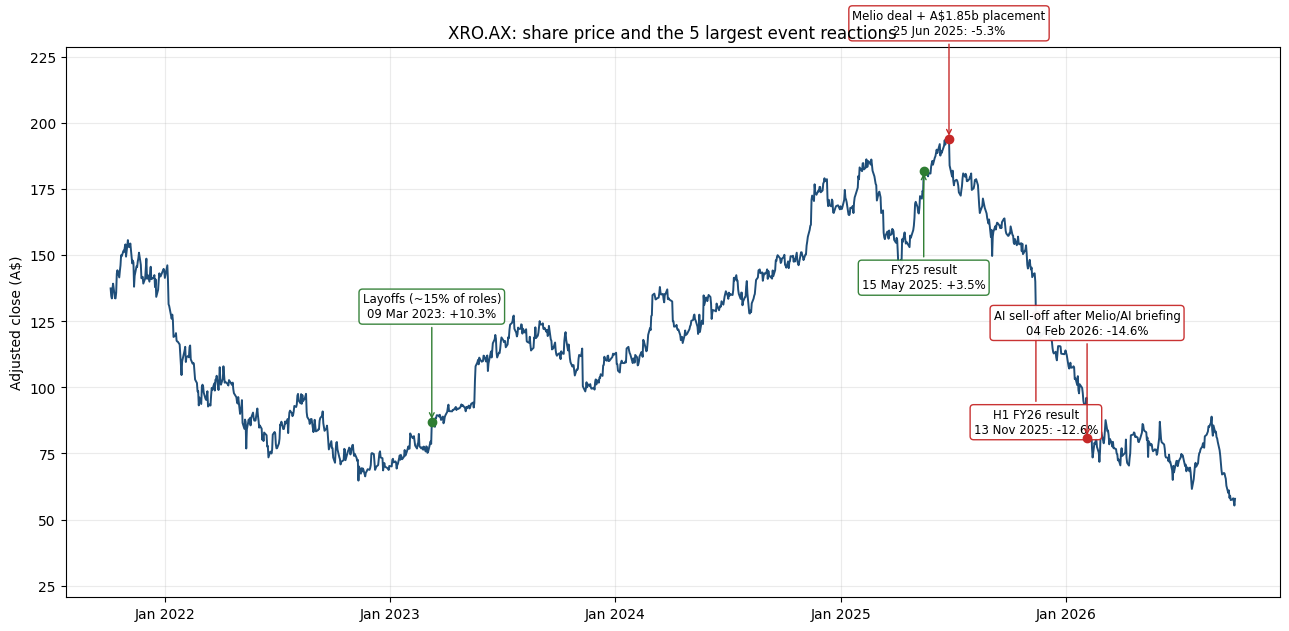

In [10]:
fig = plot_price_with_events(close, ranked.head(TOP_N), TICKER, OUTPUT_DIR / "xro_price_events.png")
plt.show()

## Caveats to state if you use this on a slide
- **A price move is not proof of cause.** Several moves coincide with broad software-sector sell-offs. Ranking by the move *relative to a benchmark* (e.g. the ASX 200) would isolate the Xero-specific part.
- **The ranking depends on your candidate list.** An event you did not list cannot appear.
- **Verify the flagged dates** against ASX announcements.
- **Yahoo Finance data is unofficial.** Spot-check a few price levels against another source and cite Yahoo Finance.